In [1]:
import torch
import torchvision
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
from skimage import io
from PIL import Image
from torchvision.transforms import v2
import torchvision.models as models

/tmp/ipykernel_117353/2556861583.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [51]:
class LoadDataset(Dataset):
    """Load dataset."""

    def __init__(self, df, transform=None):
        """
        Args:
            csv_file (string): Path to the csv file with images.
            transform (callable, optional): Optional transform to be applied
                on a sample.
        """
        self.df = df
        self.classes = {disease: i for i, disease in enumerate(df["disease_label"].unique())}
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["files"]
        label = self.df.iloc[idx]["disease_label"]
        #print(label)
        label = self.classes[label]
        #print(label)

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [25]:
%pwd

'/users/aflemis1/AI-and-Deep-Learning-Group-8--6165/scripts'

In [41]:
### read in the label df ###
label_df = pd.read_csv("../dataset/dataset_split.csv").loc[:,["files","disease_label"]].dropna(axis=0)

classes = {i: disease for i, disease in enumerate(label_df["disease_label"].unique())}
# classes
train_df, temp_df = train_test_split(label_df, test_size=0.3, stratify=label_df['disease_label'], random_state=0)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['disease_label'], random_state=0)

#train_df.iloc[0,0]

In [52]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),  # automatically scales to [0,1]
])


train_dataset = LoadDataset(train_df, transform=transform)
val_dataset   = LoadDataset(val_df, transform=transform)
test_dataset  = LoadDataset(test_df, transform=transform)


In [37]:
train_dataset

In [105]:
len(classes)


33

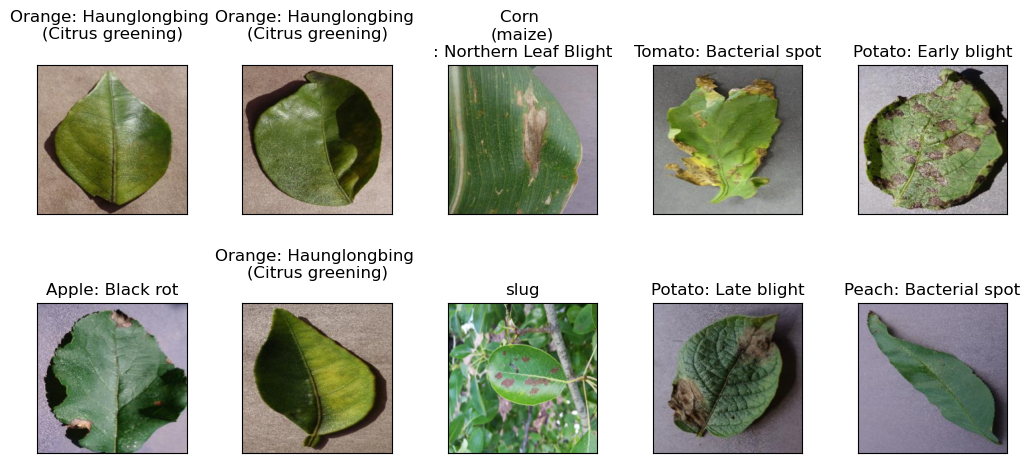

In [102]:
def show_img(x, title="", bot=""): ## bot is bottom
    plt.imshow(x)
    plt.xticks([])
    plt.yticks([])
    plt.title(title)
    plt.xlabel(bot)


plt.figure(figsize = (10,5))
for i, sample_label in enumerate(train_dataset):
    if i < 10:
        plt.subplot(2,5,i+1)
        if len(classes[sample_label[1]]) > 30:
            label = "\n(".join(classes[sample_label[1]].split("("))
            label = ")\n".join(label.split(")"))
        else:
            label = classes[sample_label[1]]

        show_img(sample_label[0].permute(1, 2, 0).numpy(), label)
    else:
        break
plt.tight_layout(h_pad=2.0, w_pad=4)
plt.show()

In [103]:
data_augmentation = v2.Compose([
    transforms.v2.RandomHorizontalFlip(p=0.5),
    transforms.v2.RandomVerticalFlip(p=0.5),
    transforms.v2.RandomRotation(degrees = (-.1,.1)),
    #transforms.v2.RandomZoomOut(p=.5),
    transforms.v2.ColorJitter(brightness = (.5,1), contrast = 0.1,
                              saturation = 0.1, hue = 0.1)
])

<Figure size 1000x1000 with 0 Axes>

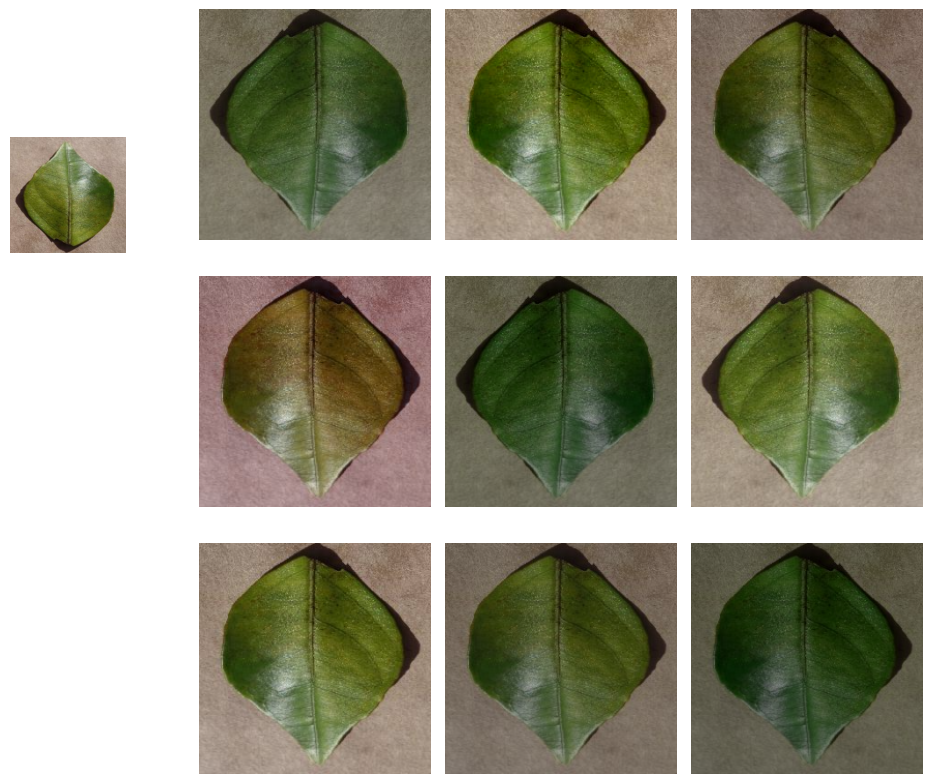

In [104]:


plt.figure(figsize=(10, 10))

for i, image_label in enumerate(train_dataset):
    plt.figure(figsize=(10,8))
    plt.subplot(6, 4, 5)
    plt.imshow(image_label[0].permute(1, 2, 0).numpy())
    plt.axis("off")


    for j in range(9):
        ax = plt.subplot(3, 4, int(j/3)*4 + 2 + (j % 3))

        show_img(data_augmentation(image_label[0]).permute(1,2,0).numpy(), "")

        plt.tight_layout()
        plt.axis("off")
    plt.tight_layout()
    if i != 1:
        break

In [14]:
# model = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
model = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)

In [23]:
#model.fc

#for layer in model.classifier[-3:]:
#    print(layer)

class test:
    def __init__(self):
        self.dog = "dog"

c = test()

c

'test'

In [30]:
train = DataLoader(train_dataset, batch_size=int(27171/2), shuffle=True)

#for i in train:
#    print(i[1])
#    print(i[0].shape)
#    break

In [28]:
len(train_dataset)

27171

In [11]:
model.state_dict()

OrderedDict([('features.0.weight',
              tensor([[[[ 1.1864e-01,  9.4069e-02,  9.5435e-02,  ...,  5.5822e-02,
                          2.1575e-02,  4.9963e-02],
                        [ 7.4882e-02,  3.8940e-02,  5.2979e-02,  ...,  2.5709e-02,
                         -1.1299e-02,  4.1590e-03],
                        [ 7.5425e-02,  3.8779e-02,  5.4930e-02,  ...,  4.3596e-02,
                          1.0225e-02,  1.3251e-02],
                        ...,
                        [ 9.3155e-02,  1.0374e-01,  6.7547e-02,  ..., -2.0277e-01,
                         -1.2839e-01, -1.1220e-01],
                        [ 4.3544e-02,  6.4916e-02,  3.6164e-02,  ..., -2.0248e-01,
                         -1.1376e-01, -1.0719e-01],
                        [ 4.7369e-02,  6.2543e-02,  2.4758e-02,  ..., -1.1844e-01,
                         -9.5567e-02, -8.3890e-02]],
              
                       [[-7.2634e-02, -5.7996e-02, -8.0661e-02,  ..., -6.0304e-04,
                         -2